# Q 1-3  
The optimal solution x*=[0 0 0 0 ..... 0] which is found by calculating the gradient of the given function and equating it to 0.

The eigen values of the Hessian matrix of the function come to be k,1, given that k>=1, we get that Beta=k, alpha=1 and kappa=Beta/alpha=k.

f(x) is convex as Hessian matrix is positive definite.

f(x) is smooth as Beta>0.

f(x) is strongly convex as alpha>0.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
class Asn1:
    def __init__(self, kappa, step_size_factor):
        self.kappa=kappa
        self.step_size=step_size_factor*1/kappa
        self.mu=0 #zero mean
        self.sigma=1 #variance=1
        self.size=100 #value of n=100
        self.scale=100 #scale factor
        self.x=None #to store the vector x
        self.T=200 #total iterations
        self.x_gd=None
        self.x_agd=None
        self.f_agd=[]
        self.f_gd=[]
        self.x_mom={0.4:None,0.6:None,0.8:None}
        self.f_mom={0.4:[],0.6:[],0.8:[]}
        self.gd_ub=[]
        self.agd_ub=[]
        self.f=pd.DataFrame()
        
    def generate_x0(self,scale,mu,sigma,size):
        self.x=scale*np.random.normal(mu,sigma,size) 
        '''generating an initial candidate solution x0 by sampling a Gaussian random vector, 
        with zero mean and variance=1, and multiplying 100 to the sampled vector'''
        
    def fnc(self,x,k): #to form the function given
        return 0.5*x[:-1]@x[:-1]+0.5*k*x[-1]**2

    def grad(self,x,k): #to compute the gradient
        temp=x.copy()
        temp[-1]=k*x[-1]
        return temp

    def grad_descent(self,x,k,lr,itr): #to compute gradient descent
        x_new=x.copy()
        for i in range(itr):
            self.f_gd.append(self.fnc(x_new,k))
            x_new-=lr*self.grad(x_new,k)
        return x_new

    def accl_grad_descent(self,x,k,lr,itr): #to compute accelerated gradient descent
        y=x.copy()
        x_new=x.copy()
        beta_2=((k**0.5)-1)/((k**0.5)+1)
        for i in range(itr):
            self.f_agd.append(self.fnc(x_new,k))
            y_old=y.copy()
            y=x_new-lr*self.grad(x_new,k)
            x_new=(1+beta_2)*y - beta_2*y_old
        return x_new

    def momentum(self,x,k,lr,itr,mu_mom): #to apply the momentum method
        x_new=x.copy()
        x_old2=x.copy()
        for i in range(itr):
            self.f_mom[mu_mom].append(self.fnc(x_new,k))
            x_old=x_new.copy()
            x_new=x_new-lr*self.grad(x_new,k)+mu_mom*(x_new-x_old2)
            x_old2=x_old.copy()
        return x_new

    def upper_bounds(self,f_gd,f_agd,k,itr): #to compute upper bounds of Theorem 3 and 5
        gamma_gd=1/(k-1)
        gamma_agd=1/(k**0.5 -1)
        for i in range(itr):
            self.gd_ub.append(f_gd[-1]+((f_gd[0]-f_gd[-1])*(1+gamma_gd)**-i))
            self.agd_ub.append(f_agd[-1]+((f_gd[0]-f_gd[-1])*(1+gamma_agd)**-i))

    def plot_graph(self,fnc,y_label): #for plotting graphs
        colors=['blue', 'green', 'red', 'violet','cyan','yellow','black','orange','lavender']
        k=0
        for i in fnc.columns:
            plt.plot(fnc.index.values,fnc[i],label=i,color=colors[k])
            k+=1
        plt.xlabel("Time")
        plt.ylabel(y_label)
        plt.legend()
        plt.show()

    def main(self):
        self.generate_x0(self.scale,self.mu,self.sigma,self.size)
        print(f"\nGenerated x vector:\n{self.x}")
        self.x_gd=self.grad_descent(self.x,self.kappa,self.step_size,self.T)
        print(f"\nPost Gradient Descent,\n x_final={self.x_gd}")
        self.x_agd=self.accl_grad_descent(self.x,self.kappa,self.step_size,self.T)
        print(f"\nPost Accl. Gradient Descent,\n x_final={self.x_agd}")
        self.x_mom[0.4]=self.momentum(self.x,self.kappa,self.step_size,self.T,0.4)
        print(f"\nIn Momentum, for mu=0.4,\n x_final={self.x_mom[0.4]}")
        self.x_mom[0.6]=self.momentum(self.x,self.kappa,self.step_size,self.T,0.6)
        print(f"\nIn Momentum, for mu=0.6,\n x_final={self.x_mom[0.6]}")
        self.x_mom[0.8]=self.momentum(self.x,self.kappa,self.step_size,self.T,0.8)
        print(f"\nIn Momentum, for mu=0.8,\n x_final={self.x_mom[0.8]}")
        self.f["Gradient Descent"]=self.f_gd.copy()
        self.f["Accl. GD"]=self.f_agd.copy()
        self.f["Momentum mu=0.4"]=self.f_mom[0.4].copy()
        self.f["Momentum mu=0.6"]=self.f_mom[0.6].copy()
        self.f["Momentum mu=0.8"]=self.f_mom[0.8].copy()
        self.upper_bounds(self.f_gd,self.f_agd,self.kappa,self.T)
        self.f["GD Upper Bound"]=self.gd_ub
        self.f["AGD Upper Bound"]=self.agd_ub
        print("\nThe dataset of f")
        display(self.f)

    def graphs(self):
        print("\nPlotting the f for first 25 iterations")
        self.plot_graph(self.f.head(25),"f_values")
        print("\nPlotting the f for all iterations")
        self.plot_graph(self.f,"f_values")
        print("\nPlotting the log10(f) for first 5 iterations")
        self.plot_graph(np.log10(self.f.head(5)),"log(f)_values")
        print("\nPlotting the log10(f) for all iterations")
        self.plot_graph(np.log10(self.f),"log(f)_values")

# Taking the value of k(kappa)=5, and step size=1/beta=0.2 where beta=k and alpha=1

In [23]:
obj1=Asn1(5,1)
obj1.main()


Generated x vector:
[ 1.76888877e+02 -1.23309968e+02  1.26780636e+02 -2.98689333e+01
 -2.11581688e+02  1.46675151e+02  1.71292254e+02 -1.05217101e+02
  4.09027107e+01  7.86296447e+01  5.63598881e+01  1.72164808e+01
 -4.05244547e+01  2.37187076e+02 -1.64850712e+00 -3.56131082e+01
 -2.57008690e+01 -1.17185851e+02 -4.00417434e+01 -8.00902740e+01
 -7.77141137e+01  6.97331461e+01  3.52897285e+01  6.47387095e+00
 -2.31946137e+02  1.86833122e+01  2.55465325e+01 -6.51279615e+01
  5.79304235e+01  2.89342248e+01  1.32841769e+01 -1.09630953e+02
  1.27988816e+02  6.44096234e+01  8.70771090e+01  1.19925844e+02
 -1.23126638e+02  6.39934306e+01 -6.39647511e+01  8.82139377e+01
  9.33285524e-01  2.30021630e+01  6.53824899e-02 -8.86077467e+01
  5.89060833e+00 -1.31673431e+02 -8.33245832e+01 -1.00788064e+02
 -8.25626059e+01  4.90866404e+01 -8.88086683e+01  1.35675297e+02
  2.81642477e+01 -5.75529051e+01  1.88585329e+02 -3.53785415e+01
  1.67612054e+02  4.79662692e+01  3.77973745e+01  1.27073735e+02
 -8.

,Gradient Descent,Accl. GD,Momentum mu=0.4,Momentum mu=0.6,Momentum mu=0.8,GD Upper Bound,AGD Upper Bound
0,4.850452e+05,4.850452e+05,4.850452e+05,4.850452e+05,4.850452e+05,4.850452e+05,4.850452e+05
1,3.091572e+05,2.532225e+05,3.091572e+05,3.091572e+05,3.091572e+05,3.880362e+05,2.681264e+05
2,1.978606e+05,1.180876e+05,1.518050e+05,1.313343e+05,1.125683e+05,3.104290e+05,1.482166e+05
3,1.266308e+05,5.118350e+04,5.990371e+04,2.996753e+04,8.728323e+03,2.483432e+05,8.193214e+04
4,8.104371e+04,2.105854e+04,1.903272e+04,6.397320e+02,1.554483e+04,1.986745e+05,4.529097e+04
...,...,...,...,...,...,...,...
195,7.746301e-33,7.172941e-92,9.997657e-73,4.607648e-39,3.635515e-14,6.142281e-14,3.051168e-45
196,4.957633e-33,2.214025e-92,7.068778e-73,4.808736e-41,4.651463e-14,4.913825e-14,1.686644e-45
197,3.172885e-33,6.833544e-93,3.691765e-73,2.237234e-39,3.708361e-14,3.931060e-14,9.323540e-46
198,2.030646e-33,2.109054e-93,1.549384e-73,3.998081e-39,1.859613e-14,3.144848e-14,5.153926e-46



Plotting the f for first 25 iterations


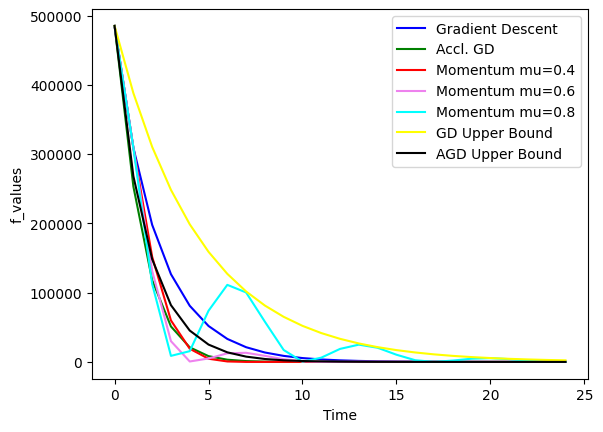


Plotting the f for all iterations


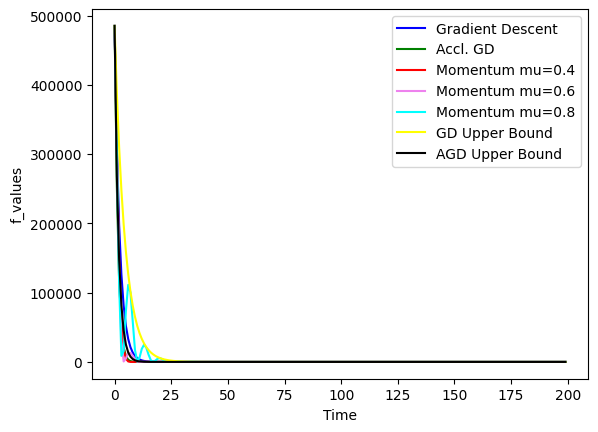


Plotting the log10(f) for first 5 iterations


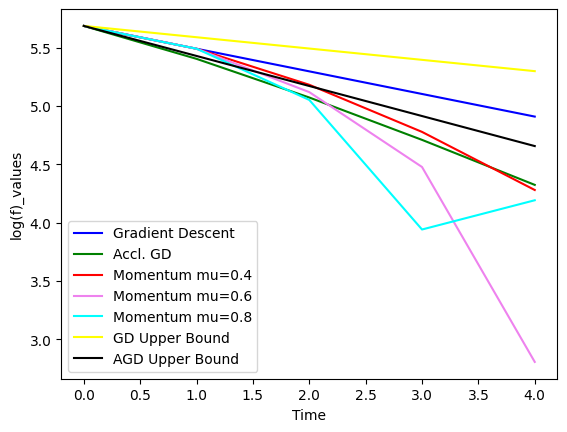


Plotting the log10(f) for all iterations


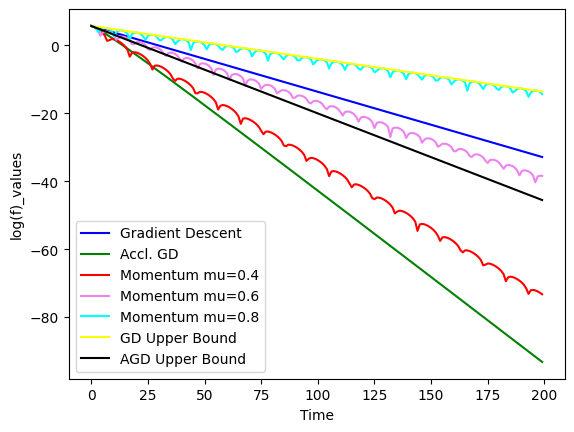

In [24]:
obj1.graphs()

# Q) 8
- We can clearly see that the convergence is the fastest for accelerated gradient descent.
- Momentum method generally converges faster than gradient descent, but its performance is sensitive to mu.
- Normally as mu increases, the convergence rate increases. We see in the plot that for mu=0.8, the convergence is fastest initially(can see in first 5 iterations)
- And a higher mu stabilises on the final solution much faster.

# Taking the value of k(kappa)=20, and step size=1/beta=0.05 where beta=k and alpha=1

In [25]:
obj2=Asn1(20,1)
obj2.main()


Generated x vector:
[ -66.22366079  137.57603064  -56.51043511   55.72371782  172.28984456
   61.46535277    4.89365528  -69.9367797   -12.69467445  -81.99418725
   77.1355934    58.20433291  -63.90027739 -188.14245282  -35.61616704
   10.23870627    9.64784125  -30.85905753 -126.50793968   91.1416119
 -252.25183154  -77.26179578  -70.99543916   28.05067699 -137.35762073
   15.26399826  127.96003004  -20.7286963   -16.55932337 -104.13396916
  -96.10278198   59.55506147  -81.09619686 -167.79994851   74.9919052
  -34.31957405   21.63975715   41.81767261  -22.49976606   32.93895226
  -56.4077938   -51.3104673    59.81595649   77.20999761  -67.18944589
   24.77078768    3.19752747 -156.9429017  -203.15101554  126.43469877
 -201.63051628  -78.53920745 -149.26382743  105.75137857   79.91210304
 -119.65172556  -77.15102701 -128.71606858   -3.73276473  -37.45653411
  -30.64542675  106.70829547  -27.65019372   14.02967512   -9.79124123
 -159.89577807   47.98403862  114.41820546  -41.73205147 -

,Gradient Descent,Accl. GD,Momentum mu=0.4,Momentum mu=0.6,Momentum mu=0.8,GD Upper Bound,AGD Upper Bound
0,586647.243287,5.866472e+05,5.866472e+05,5.866472e+05,5.866472e+05,586647.243287,5.866472e+05
1,477666.559172,4.693958e+05,4.776666e+05,4.776666e+05,4.776666e+05,557314.881158,4.554689e+05
2,431094.069653,3.585752e+05,4.213794e+05,4.235661e+05,4.304487e+05,529449.137136,3.536230e+05
3,389062.397861,2.778690e+05,3.499031e+05,3.314081e+05,3.207202e+05,502976.680316,2.745505e+05
4,351128.814070,2.093695e+05,2.922059e+05,2.525778e+05,2.053156e+05,477827.846336,2.131591e+05
...,...,...,...,...,...,...,...
195,0.001086,9.623751e-35,9.486856e-11,1.357970e-31,6.712691e-14,26.576136,2.159301e-16
196,0.000980,5.859084e-35,7.870741e-11,8.691013e-32,6.124057e-14,25.247365,1.676467e-16
197,0.000885,3.566923e-35,6.529935e-11,5.562250e-32,4.980797e-14,23.985033,1.301598e-16
198,0.000798,2.171384e-35,5.417540e-11,3.559841e-32,4.378224e-14,22.785818,1.010551e-16



Plotting the f for first 25 iterations


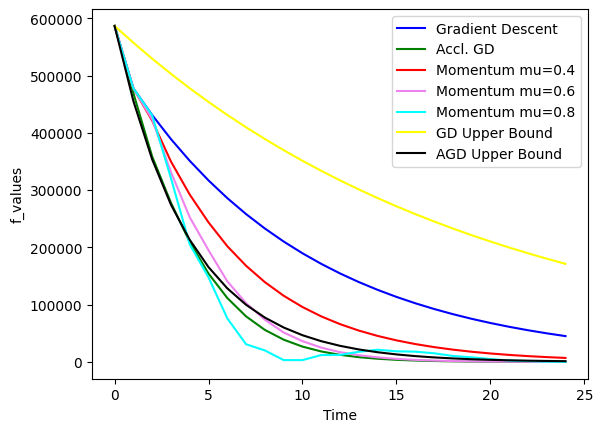


Plotting the f for all iterations


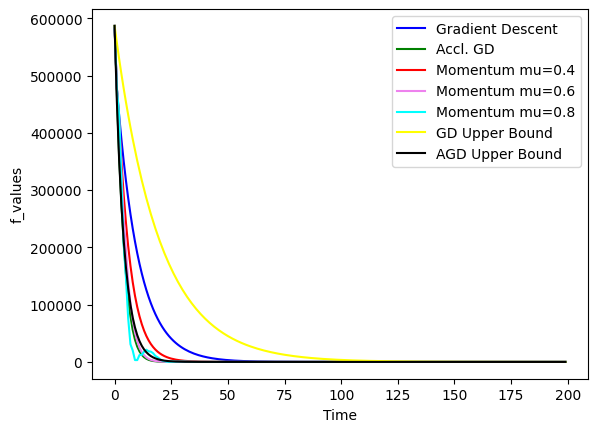


Plotting the log10(f) for first 5 iterations


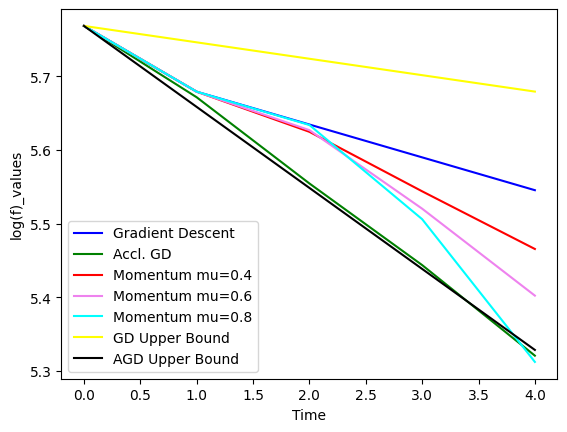


Plotting the log10(f) for all iterations


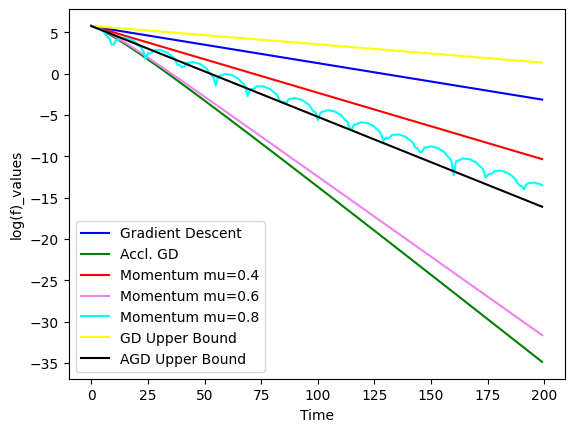

In [26]:
obj2.graphs()

# Taking the value of k(kappa)=50, and step size=1/beta=0.02 where beta=k and alpha=1

In [27]:
obj3=Asn1(50,1)
obj3.main()


Generated x vector:
[  36.00037554    6.5325649  -127.52488294  -27.16984817  145.43104597
  -32.34736115   20.12019059  -79.11937968  -25.18980391   -5.79567508
   57.08451511   30.72081493  -21.42286937   56.60245506  -40.21375746
   21.44996796   26.37445203  135.49127531  111.63408823  186.05533546
  -11.35404563   96.2569093  -214.71768687   92.76660631    8.69778248
 -381.7303742    27.18861921  -34.76805772   10.910622      3.37249417
  -18.81977045   41.06936849   62.70106963  104.02985702  118.10966757
   90.98332036 -134.60849045 -142.61876299  123.32595632 -156.40478747
   10.74610172   77.26941612  105.50985219  135.1637607   -46.59205118
   16.98234606  176.94476114  -69.10642183 -223.23897574  182.62706652
 -140.63307217  -40.23428963  133.56261912   70.29994484  -70.99623238
 -105.91039246  136.81496658  163.1980631   -85.59199209  -79.61097588
  129.73539513   16.28114645  158.03995457  147.12164341 -135.90522931
   20.80731579   14.24374877    6.58293466  -49.25813001

,Gradient Descent,Accl. GD,Momentum mu=0.4,Momentum mu=0.6,Momentum mu=0.8,GD Upper Bound,AGD Upper Bound
0,694210.501647,6.942105e+05,694210.501647,694210.501647,6.942105e+05,694210.501647,6.940402e+05
1,507929.030931,5.860037e+05,507929.030931,507929.030931,5.079290e+05,680329.698511,5.958881e+05
2,487815.041306,4.474662e+05,506176.124577,535222.627036,5.775131e+05,666726.511438,5.116168e+05
3,468497.565670,3.986102e+05,454122.928341,459841.476743,4.932883e+05,653395.388106,4.392632e+05
4,449945.062070,3.493180e+05,422168.614313,403277.264342,3.769455e+05,640330.887241,3.771420e+05
...,...,...,...,...,...,...,...
195,200.225969,5.000539e-18,0.728214,0.000189,1.504753e-13,13674.560334,8.482044e-08
196,192.297021,3.722578e-18,0.679343,0.000169,1.189892e-13,13404.476025,7.282502e-08
197,184.682059,2.771085e-18,0.633752,0.000151,8.759937e-14,13139.793401,6.252601e-08
198,177.368649,2.062696e-18,0.591221,0.000135,8.182436e-14,12880.404430,5.368349e-08



Plotting the f for first 25 iterations


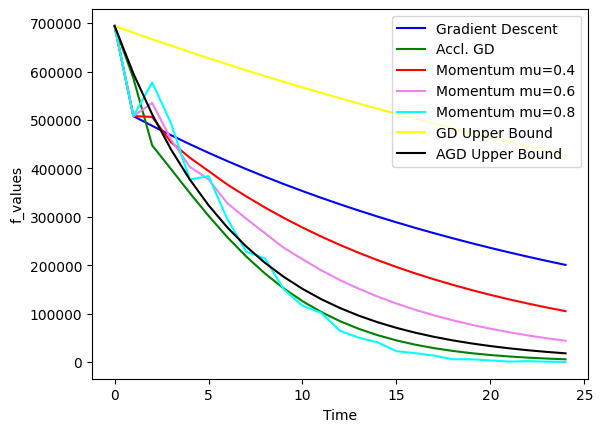


Plotting the f for all iterations


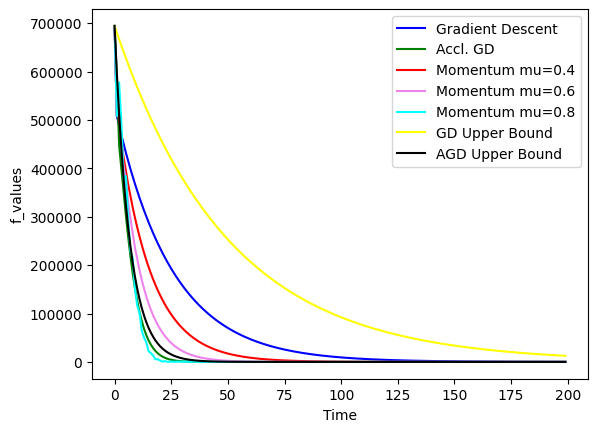


Plotting the log10(f) for first 5 iterations


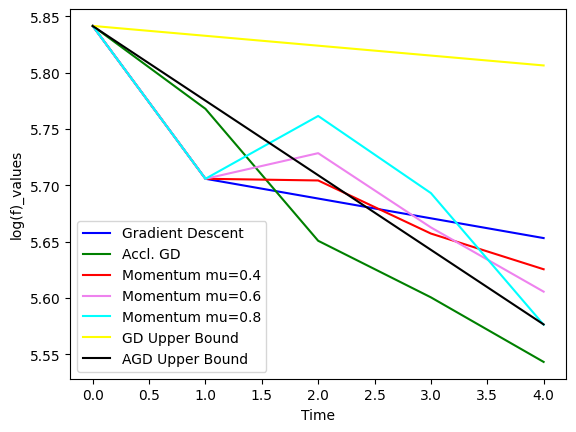


Plotting the log10(f) for all iterations


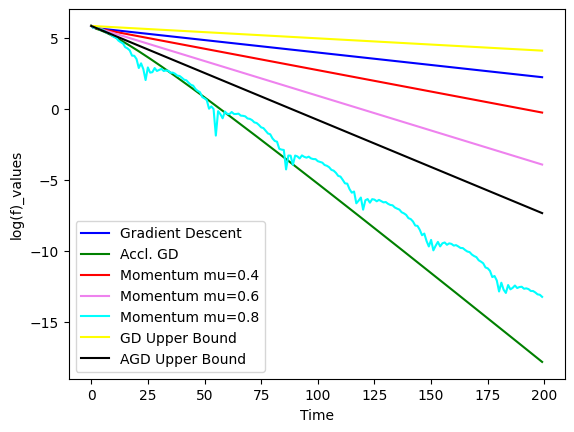

In [28]:
obj3.graphs()

# Taking the value of k(kappa)=5, and step size= 2* 1/beta = 0.4 where beta=k and alpha=1

In [29]:
obj4=Asn1(5,2)
obj4.main()


Generated x vector:
[  77.51167443  -45.77356187  -22.98856408    9.60521609 -122.46046064
  -92.85947096  -17.3383508   -80.00002268   92.20795055  -50.12538418
  -61.93807619  -58.41347262    7.00426588  -37.16402314  -26.98467423
  -19.67546699  -58.19383443  131.60604558  155.78197203 -109.08099007
  157.2096606    42.3271106  -189.24860117  143.33806638  -37.34940523
 -253.59603138 -110.7196792   121.39071638  120.2386736    -2.83355484
 -118.81554397  -69.66248855  -70.07115941   26.06616303 -145.25286905
   49.91443063  -75.7989219    89.34812086 -166.1609561    20.11512604
   -8.01262807  -49.53291033   -7.35729259 -113.87485021  -41.57701379
   12.56424293   31.08443951  -71.62857766   44.4260904    -1.55563301
  153.7299154    -5.24725133  -46.42597184 -114.07860038  -43.7903682
   34.19311943  -35.06009998 -121.46273089  115.57883976  -17.53254981
   -9.43806639   34.60912027   -4.20360947   28.91227047 -108.87658025
  -86.54688615   82.57541481  -17.5796825   -17.85270052 

,Gradient Descent,Accl. GD,Momentum mu=0.4,Momentum mu=0.6,Momentum mu=0.8,GD Upper Bound,AGD Upper Bound
0,417989.981132,4.179900e+05,4.179900e+05,4.179900e+05,4.179900e+05,417989.981132,2.769930e+87
1,160610.260963,1.296985e+05,1.606103e+05,1.606103e+05,1.606103e+05,337558.818579,2.769930e+87
2,67953.561702,1.339574e+05,1.671960e+04,6.424410e+03,6.343750e+03,273213.888537,2.769930e+87
3,34597.149968,3.308481e+05,1.884848e+03,2.608470e+04,8.570000e+04,221737.944503,2.769930e+87
4,22588.841744,8.656486e+05,6.764908e+03,4.447969e+04,1.587812e+05,180557.189276,2.769930e+87
...,...,...,...,...,...,...,...
195,15834.168368,5.896139e+85,7.956447e-73,1.846924e-39,2.996418e-14,15834.168368,2.769930e+87
196,15834.168368,1.543629e+86,4.624228e-73,5.362780e-39,4.354754e-14,15834.168368,2.769930e+87
197,15834.168368,4.041274e+86,9.771949e-74,8.190529e-39,2.442943e-14,15834.168368,2.769930e+87
198,15834.168368,1.058019e+87,1.536647e-75,3.891758e-39,2.965395e-15,15834.168368,2.769930e+87



Plotting the f for first 25 iterations


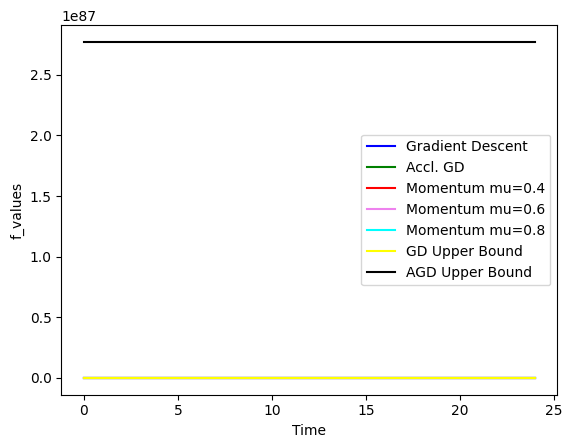


Plotting the f for all iterations


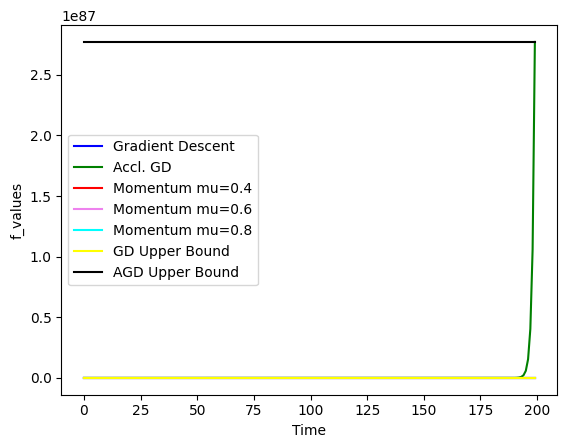


Plotting the log10(f) for first 5 iterations


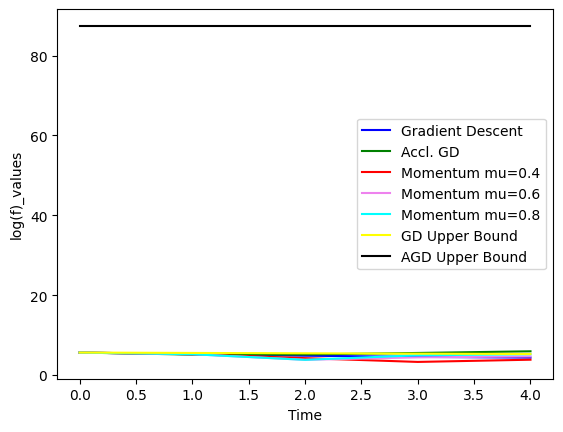


Plotting the log10(f) for all iterations


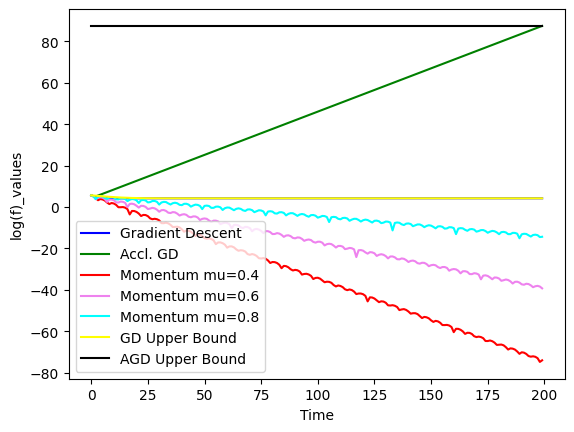

In [30]:
obj4.graphs()